In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("D:\Data Science\Sales Forecasting Project\Clean Dataset for modelling\walmart_features.csv")
print(f": {df.shape[0]:,} rows, {df.shape[1]} columns")


: 421,570 rows, 24 columns


In [6]:
# Define Features and Target:

feature_cols = [
    "store", "dept",
    "is_holiday", "store_type", "store_size",
    "temperature", "fuel_price",
    "markdown1", "markdown2", "markdown3", "markdown5",
    "cpi", "unemployment_log",
    "has_markdown",
    "month", "is_quarter_end"
]
# dropped week_of_year, quarter, year, markdown4,
#  total_markdown, store_type based on correlation + VIF

target = "weekly_sales_log"   # Log transformed target

X = df[feature_cols]
y = df[target]

print(f" Features : {X.shape[1]}")
print(f" Target   : {target}")

 Features : 16
 Target   : weekly_sales_log


In [7]:
# Train Test Split FIRST:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)

print(f"\n Train : {X_train.shape[0]:,} rows")
print(f" Test  : {X_test.shape[0]:,} rows")


 Train : 337,256 rows
 Test  : 84,314 rows


In [9]:
#  Scale AFTER Split:

# Columns that need scaling — continuous features only
cols_to_scale = [
    "store_size", "temperature", "fuel_price",
    "markdown1", "markdown2", "markdown3", "markdown5",
    "cpi", "unemployment_log"
]

scaler = StandardScaler()

# fit_transform on TRAIN only 
# fit()          → learns mean and std FROM TRAIN DATA ONLY
# transform()    → applies scaling using learned mean/std
# fit_transform  → does both in one step

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(
    X_train[cols_to_scale]   
)

# transform on TEST only — NOT fit_transform 
# Use the SAME mean/std learned from train
X_test_scaled[cols_to_scale] = scaler.transform(
    X_test[cols_to_scale]     
)
print(f"\n── Train means after scaling (should be ~0) ──")
print(X_train_scaled[cols_to_scale].mean().round(4))


── Train means after scaling (should be ~0) ──
store_size          0.0
temperature         0.0
fuel_price          0.0
markdown1          -0.0
markdown2           0.0
markdown3          -0.0
markdown5          -0.0
cpi                -0.0
unemployment_log   -0.0
dtype: float64


In [10]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Predict and Evaluate log scale
y_pred_log = lr.predict(X_test_scaled)

# Evaluate on log scale — no reverse transform issues
mae_log  = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2       = r2_score(y_test, y_pred_log)

print("LINEAR REGRESSION — MODEL PERFORMANCE (Log Scale)")
print(f"MAE  (log) : {mae_log:.4f}")
print(f"RMSE (log) : {rmse_log:.4f}")
print(f"R²         : {r2:.4f}")

# Reverse transform for dollar interpretation \
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test.values)

mae_actual  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"\nMAE  (actual $) : ${mae_actual:,.2f}")
print(f"RMSE (actual $) : ${rmse_actual:,.2f}")

LINEAR REGRESSION — MODEL PERFORMANCE (Log Scale)
MAE  (log) : 0.6496
RMSE (log) : 0.7782
R²         : 0.1046

MAE  (actual $) : $13,024.27
RMSE (actual $) : $22,848.36


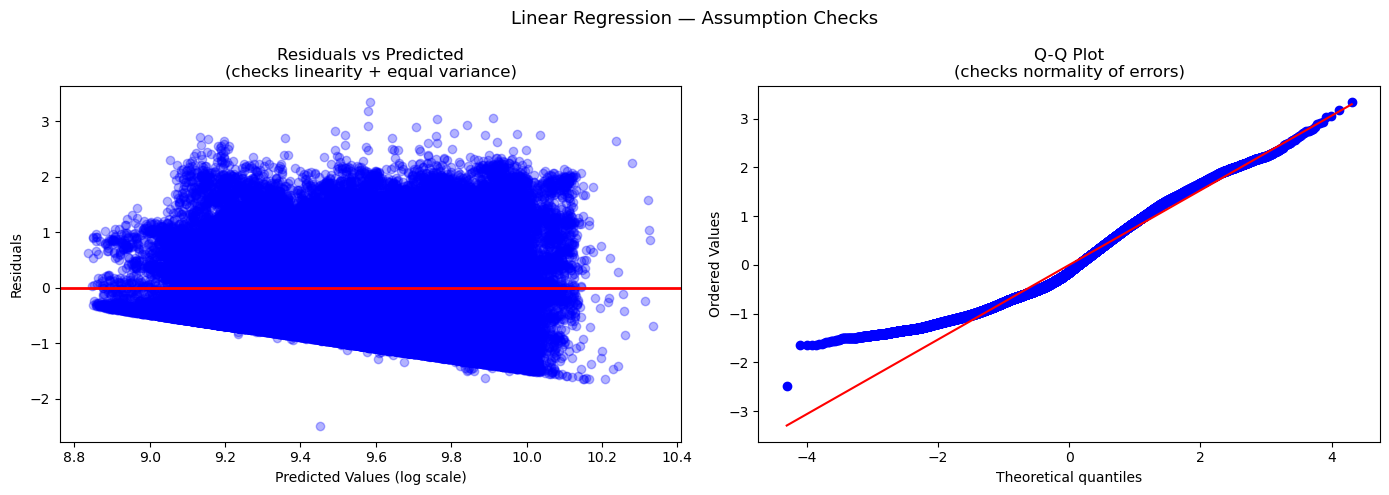

In [14]:
import scipy.stats as stats
# Residuals = actual - predicted
residuals = y_test.values - y_pred_log

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Predicted 
# Checks linearity + homoscedasticity together
# Good → residuals scattered randomly around 0
# Bad  → pattern/funnel shape visible

axes[0].scatter(y_pred_log, residuals, alpha=0.3, color="blue")
axes[0].axhline(y=0, color="red", linewidth=2)
axes[0].set_xlabel("Predicted Values (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted\n(checks linearity + equal variance)")

# Plot 2: Q-Q Plot 
# Checks normality of errors
# Good → points follow the diagonal line closely
# Bad  → points deviate from diagonal (S-curve or curved)

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot\n(checks normality of errors)")

plt.suptitle("Linear Regression — Assumption Checks", fontsize=13)
plt.tight_layout()
plt.show()